# Modelo Determinista Ajustado

## Tarea. Modelo de saturación para crecimiento de usuarios

### Planteamiento del problema
Una aplicación móvil nueva comienza a ganar usuarios durante sus primeras semanas. Al inicio el crecimiento es rápido, pero conforme pasa el tiempo, el número de usuarios se acerca a un límite máximo debido a que el mercado disponible no es infinito.

### Formulación del problema
Se busca representar el número de usuarios como una variable que cambia con el tiempo. 
Denotamos por $U(t)$ la cantidad de usuarios en el tiempo $t$, donde t se mide en semanas.
El número máximo esperado de usuarios se considera aproximadamente constante, con valor:  

$$L=10000\, (Usuarios) $$ 

El objetivo es encontrar un valor de la constante $k$ que permita simular y predecir de la mejor manera posible los datos observados.


### Datos, variables, parámetros, hipótesis y supuestos


#### Datos observados

Se registró el número acumulado de usuarios durante 12 semanas:

| Semana | Usuarios observados |
| -----: | ------------------: |
|      1 |                 950 |
|      2 |                1800 |
|      3 |                2650 |
|      4 |                3400 |
|      5 |                4100 |
|      6 |                4800 |
|      7 |                5400 |
|      8 |                5900 |
|      9 |                6350 |
|     10 |                6750 |
|     11 |                7100 |
|     12 |                7400 |



#### Variables
Las cantidades que cambian durante el proceso son las siguientes:
- $t:$ tiempo, medido en semanas.  
- $U(t):$ número de usuarios acumulados en la semana (t).  

#### Parámetros

Las cantidades que se consideran fijas durante la simulación o se desean ajustar son las siguientes:
- $k$ es una constante que llamamos parámetro de crecimiento.
- $L$ es el número máximo esperado de usuarios.
Supongamos que, por estudios previos, se estima que el máximo esperado es $L=10000$.

#### Hipótesis y supuestos del modelo
- Se considera constante $L$ el número máximo esperado de usuarios.
- Se considera constante el parámetro de crecimiento
- Se considera que el número de usuarios crece de acuerdo con una función de saturación, proporcional al término $1-e^{-kt}$.



### Modelo matemático
Para modelar este comportamiento se propone el siguiente **modelo de saturación**:

$$
U(t)=L\left(1-e^{-kt}\right)
$$

donde:

* $U(t)$ es el número de usuarios acumulados en la semana (t),
* $L$ es el número máximo esperado de usuarios,
* $k$ es el parámetro de crecimiento,
* $t$ es el tiempo medido en semanas.

Por lo tanto, el modelo queda como:

$$
U(t)=10000\left(1-e^{-kt}\right)
$$
El parámetro que se desea estimar es $k$, ya que queremos encontrar el valor que mejor describe la variación en la cantidad de usuarios.

# Actividades

## Parte 1. Probar el modelo con un parámetro dado

Se usa inicialmente $k=0.10$

1. Se define una función en Python para el modelo:

$$
U(t)=10000\left(1-e^{-kt}\right)
$$


In [46]:
# Importamos las librerias 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [47]:
def simular_usuarios(k, L, semanas_totales):
    semanas = np.arange(1, semanas_totales + 1)
    usuarios = []
    
    for t in semanas:
        U = L*(1-np.exp(-k*t))
        usuarios.append(U)

    df_modelo = pd.DataFrame({
        "semana": semanas,
        "usuarios_modelo": usuarios
    })

    return df_modelo

2. Se calculan los valores estimados por el modelo para las semanas $1,2,\ldots,12$.

In [48]:
L = 10000
k = 0.10 # Probamos primero con k=0.10
semanas_totales = 12

df_modelo = simular_usuarios(k, L, semanas_totales)

df_modelo

,semana,usuarios_modelo
0,1,951.625820
1,2,1812.692469
2,3,2591.817793
3,4,3296.799540
4,5,3934.693403
5,6,4511.883639
6,7,5034.146962
7,8,5506.710359
8,9,5934.303403
9,10,6321.205588


3. Construye un `DataFrame` con las columnas:

```python
semana
usuarios_observados
usuarios_modelo
```


In [49]:
# Carpeta para datos observados
datos_dir = Path("TareaSem2_clase1_datos")
# Ruta del archivo
csv_path = datos_dir / "datosUsuarios.csv"
# Leer el csv
df_obs = pd.read_csv(csv_path)
print(f"Archivo cargado de: {csv_path.resolve()}")
df_obs

Archivo cargado de: C:\Users\famil\Documents\MathModWorkI\Mathematical-modeling-workshop-I\TareaSem2_clase1_datos\datosUsuarios.csv


,semana,usuarios_observados
0,1,950
1,2,1800
2,3,2650
3,4,3400
4,5,4100
5,6,4800
6,7,5400
7,8,5900
8,9,6350
9,10,6750


In [50]:
df_comparacion = pd.merge(df_obs, df_modelo, on="semana")
df_comparacion

,semana,usuarios_observados,usuarios_modelo
0,1,950,951.625820
1,2,1800,1812.692469
2,3,2650,2591.817793
3,4,3400,3296.799540
4,5,4100,3934.693403
5,6,4800,4511.883639
6,7,5400,5034.146962
7,8,5900,5506.710359
8,9,6350,5934.303403
9,10,6750,6321.205588



4. Grafica en una misma figura:

* los usuarios observados,
* los usuarios estimados por el modelo.

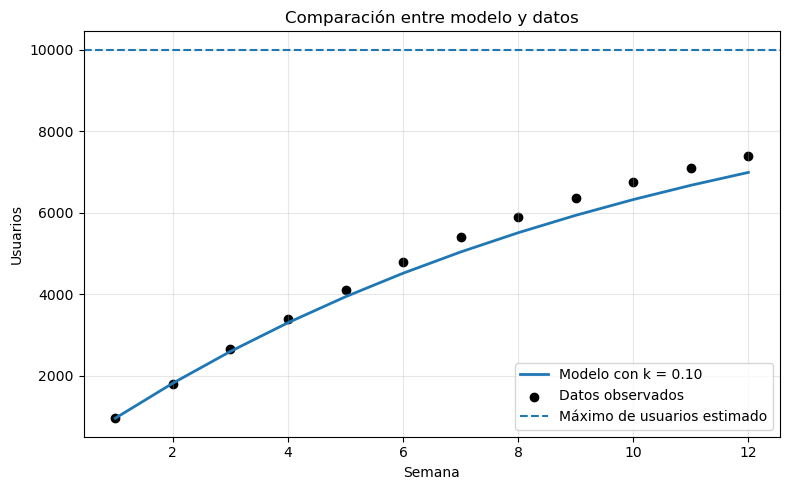

In [51]:
# Crear figura
plt.figure(figsize=(8, 5))

plt.plot(
    df_comparacion["semana"],
    df_comparacion["usuarios_modelo"],
    label="Modelo con k = 0.10",
    linewidth=2
)

plt.scatter(
    df_comparacion["semana"],
    df_comparacion["usuarios_observados"],
    label="Datos observados",
    color="black"
)

plt.axhline(
    y=L,
    linestyle="--",
    label="Máximo de usuarios estimado"
)

plt.xlabel("Semana")
plt.ylabel("Usuarios")
plt.title("Comparación entre modelo y datos")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

5. Interpreta visualmente si el modelo con (k=0.10) se ajusta bien a los datos.

El modelo con el parámetro $k=0.10$ se ajusta bien a los datos entre la semana 1 y la semana 5, a partir de la semana 6 el modelo muestra una subestimación de la cantidad de usuarios observados y con forme avanzan las semanas el modelo se aleja mas de los datos reales.

## Parte 2. Métricas de error

Calcula las siguientes métricas de error:

### Error absoluto medio

$$
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

### Error cuadrático medio

$$
MSE=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

### Raíz del error cuadrático medio

$$
RMSE=\sqrt{MSE}
$$

donde:

* $y_i$ representa los datos observados,
* $\hat{y}_i$ representa los valores estimados por el modelo.

Responde:

1. ¿Cuál es el MAE del modelo?
2. ¿Cuál es el MSE?
3. ¿Cuál es el RMSE?
4. ¿El error es grande o pequeño en comparación con el número de usuarios?



In [52]:

df_comparacion["error"] = (
    df_comparacion["usuarios_observados"]
    - df_comparacion["usuarios_modelo"]
)

df_comparacion["error_absoluto"] = np.abs(df_comparacion["error"])
df_comparacion["error_cuadratico"] = df_comparacion["error"] ** 2

df_comparacion

,semana,usuarios_observados,usuarios_modelo,error,error_absoluto,error_cuadratico
0,1,950,951.625820,-1.625820,1.625820,2.643290
1,2,1800,1812.692469,-12.692469,12.692469,161.098775
2,3,2650,2591.817793,58.182207,58.182207,3385.169190
3,4,3400,3296.799540,103.200460,103.200460,10650.335018
4,5,4100,3934.693403,165.306597,165.306597,27326.271053
5,6,4800,4511.883639,288.116361,288.116361,83011.037441
6,7,5400,5034.146962,365.853038,365.853038,133848.445351
7,8,5900,5506.710359,393.289641,393.289641,154676.741853
8,9,6350,5934.303403,415.696597,415.696597,172803.661095
9,10,6750,6321.205588,428.794412,428.794412,183864.647518


In [53]:
mae = df_comparacion["error_absoluto"].mean()
mse = df_comparacion["error_cuadratico"].mean()
rmse = np.sqrt(mse)

# Crear tabla de métricas
df_metricas = pd.DataFrame({
    "metrica": ["MAE", "MSE", "RMSE"],
    "valor": [mae, mse, rmse],
    "descripcion": [
        "Error absoluto medio",
        "Error cuadrático medio",
        "Raíz del error cuadrático medio"
    ]
})



df_metricas

,metrica,valor,descripcion
0,MAE,256.117547,Error absoluto medio
1,MSE,93601.611820,Error cuadrático medio
2,RMSE,305.943805,Raíz del error cuadrático medio


¿El error es grande o pequeño en comparación con el número de usuarios?  

Para poder decidir si el error es grande o pequeño en comparación con el número de usuarios se puede calcular el Error relativo, ya que toma el rango de los datos experimentales para comparar el error.
$$
\text{Error relativo} =
\frac{RMSE}{y_{\max}-y_{\min}}
$$

donde $y_{\max}$ y $y_{\min}$ son el valor máximo y mínimo observados de la variable de interés.


In [54]:
y_max = df_comparacion["usuarios_observados"].max()
y_min = df_comparacion["usuarios_observados"].min()

rango = y_max - y_min

error_relativo = rmse / rango
error_relativo_porcentaje = error_relativo * 100

df_decision = pd.DataFrame({
    "criterio": ["MAE", "RMSE", "valor_maximo_observado", "valor_minimo_observado", "rango_observado", "error_relativo", "error_relativo_porcentaje"],
    "valor": [mae, rmse, y_max, y_min, rango, error_relativo, error_relativo_porcentaje],
    "unidad": ["Usuarios", "Usuarios", "Usuarios", "Usuarios", "Usuarios", "proporción", "%"]
})
df_decision

,criterio,valor,unidad
0,MAE,256.117547,Usuarios
1,RMSE,305.943805,Usuarios
2,valor_maximo_observado,7400.000000,Usuarios
3,valor_minimo_observado,950.000000,Usuarios
4,rango_observado,6450.000000,Usuarios
5,error_relativo,0.047433,proporción
6,error_relativo_porcentaje,4.743315,%


Como el error relativo es del $4.7\%$ podemos decir que el error es pequeño en comparación a los datos, 
también podemos decir que como el RMSE y el MAE son distintos por 50 unidades entonces hay errores puntuales, en este caso, los errores puntuales se presentan a partir de la semana 6.

## Parte 3. Ajuste del parámetro $k$

Ahora prueba varios valores posibles para (k):

$$
k \in \{0.05, 0.06, 0.07, \ldots, 0.20\}
$$

1. Para cada valor de (k), calcula los valores estimados por el modelo.
2. Calcula el MAE, MSE y RMSE.
3. Guarda los resultados en un `DataFrame` con columnas:

```python
k
MAE
MSE
RMSE
```

In [55]:
L = 10000
# Búsqueda de valores de k
valores_k = np.arange(0.05, 0.21, 0.01)

resultados = []

for k in valores_k:
    df_modelo = simular_usuarios(k, L, semanas_totales)

    df_comparacion = pd.merge(df_obs, df_modelo, on="semana")

    error = (
        df_comparacion["usuarios_observados"]
        - df_comparacion["usuarios_modelo"]
    )

    mae = np.mean(np.abs(error))
    mse = np.mean(error**2)
    rmse = np.sqrt(mse)

    resultados.append({
        "k": k,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })

df_resultados = pd.DataFrame(resultados)

df_resultados

,k,MAE,MSE,RMSE
0,0.05,2050.044141,4.847631e+06,2201.733561
1,0.06,1633.392733,3.075298e+06,1753.652702
2,0.07,1247.992589,1.801992e+06,1342.383084
3,0.08,891.165814,9.307644e+05,964.761339
4,0.09,560.481351,3.827103e+05,618.635820
5,0.10,256.117547,9.360161e+04,305.943805
6,0.11,93.718420,1.115316e+04,105.608507
7,0.12,295.809904,9.280538e+04,304.639749
8,0.13,542.084283,3.039240e+05,551.293039
9,0.14,771.424459,6.163369e+05,785.071252


4. Encuentra el valor de $k$ que produce el menor RMSE.

In [56]:
mejor = df_resultados.loc[df_resultados["RMSE"].idxmin()]

print("Mejor valor encontrado:")
print(mejor)

Mejor valor encontrado:
k           0.110000
MAE        93.718420
MSE     11153.156792
RMSE      105.608507
Name: 6, dtype: float64


5. Grafica el RMSE contra $k$.

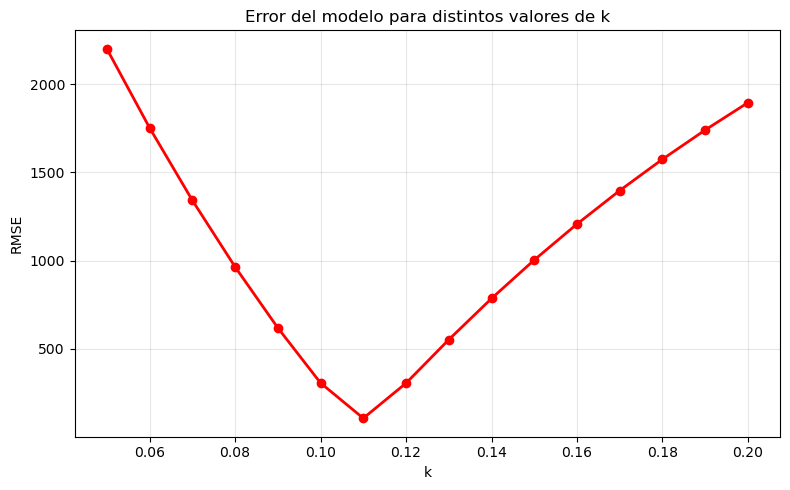

In [57]:
# Crear figura
plt.figure(figsize=(8, 5))

plt.plot(
    df_resultados["k"],
    df_resultados["RMSE"],
    marker="o",
    linewidth=2,
    color="red"
)

plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("Error del modelo para distintos valores de k")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Responde:
1. ¿Cuál es el mejor valor de $k$?
Mejor valor encontrado:
k           0.110000
2. ¿Cuál fue el menor RMSE obtenido?
RMSE      105.608507
3. ¿Qué significa que un valor de (k) tenga menor RMSE que otro?
Significa que el modelo con el valor de $k$ que minimiza el RMSE genera los resultados que se acercan más a los resultados reales, es decir, encuentra el valor de k que describe mejór el comportamiento real de los datos.
4. ¿El modelo mejora respecto al caso inicial $k=0.10$?
Existe una mejora, en el caso inicial con $k=0.10$ se tiene un RMSE de 305.943805 y con $k=0.11$ el RMSE es 105.608507, es decir, con el cambio de $k$ disminuye el error RMSE a un tercio de su valor, y por lo tanto, se ajusta mejor el modelo a los datos reales.

## Parte 4. Modelo con el mejor parámetro

Usando el mejor valor de $k$ encontrado:

1. Calcula nuevamente los valores estimados por el modelo.

In [58]:
L = 10000
k = 0.11 
semanas_totales = 12

df_modelo_optimizado = simular_usuarios(k, L, semanas_totales)

df_modelo_optimizado

,semana,usuarios_modelo
0,1,1041.658647
1,2,1974.812020
2,3,2810.762666
3,4,3559.635789
4,5,4230.501896
5,6,4831.486655
6,7,5369.869317
7,8,5852.170883
8,9,6284.233090
9,10,6671.289163


2. Grafica los datos observados y el modelo ajustado.

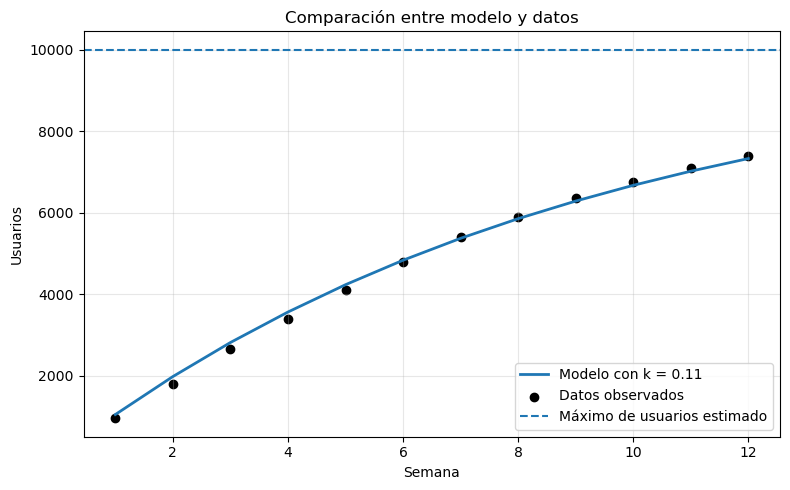

In [59]:
# Crear figura
plt.figure(figsize=(8, 5))

plt.plot(
    df_modelo_optimizado["semana"],
    df_modelo_optimizado["usuarios_modelo"],
    label="Modelo con k = 0.11",
    linewidth=2
)

plt.scatter(
    df_obs["semana"],
    df_obs["usuarios_observados"],
    label="Datos observados",
    color="black"
)

plt.axhline(
    y=L,
    linestyle="--",
    label="Máximo de usuarios estimado"
)

plt.xlabel("Semana")
plt.ylabel("Usuarios")
plt.title("Comparación entre modelo y datos")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

3. Compara visualmente el modelo inicial con $k=0.10$ y el modelo ajustado.

In [60]:
k = 0.10
L = 10000
df_modelo_k_inicial = simular_usuarios(k, L, semanas_totales)
df_modelo_optimizado.rename(columns={'usuarios_modelo': 'usuarios_k_0.11'}, inplace=True)
df_modelo_k_inicial.rename(columns={'usuarios_modelo': 'usuarios_k_0.10'}, inplace=True)

df_comparacion_modelos = pd.merge(pd.merge(df_obs, df_modelo_k_inicial, on="semana"), df_modelo_optimizado, on="semana")

df_comparacion_modelos

,semana,usuarios_observados,usuarios_k_0.10,usuarios_k_0.11
0,1,950,951.625820,1041.658647
1,2,1800,1812.692469,1974.812020
2,3,2650,2591.817793,2810.762666
3,4,3400,3296.799540,3559.635789
4,5,4100,3934.693403,4230.501896
5,6,4800,4511.883639,4831.486655
6,7,5400,5034.146962,5369.869317
7,8,5900,5506.710359,5852.170883
8,9,6350,5934.303403,6284.233090
9,10,6750,6321.205588,6671.289163


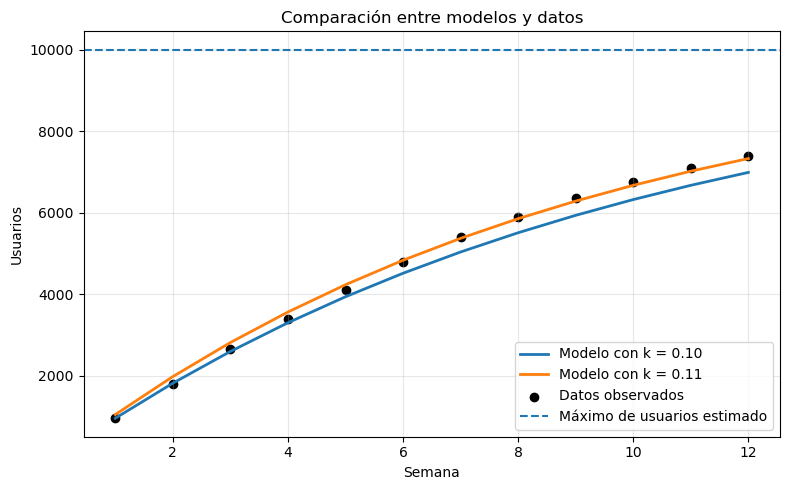

In [61]:
# Crear figura
plt.figure(figsize=(8, 5))

plt.plot(
    df_comparacion_modelos["semana"],
    df_comparacion_modelos["usuarios_k_0.10"],
    label="Modelo con k = 0.10",
    linewidth=2
)

plt.plot(
    df_comparacion_modelos["semana"],
    df_comparacion_modelos["usuarios_k_0.11"],
    label="Modelo con k = 0.11",
    linewidth=2
)

plt.scatter(
    df_comparacion_modelos["semana"],
    df_comparacion_modelos["usuarios_observados"],
    label="Datos observados",
    color="black"
)

plt.axhline(
    y=L,
    linestyle="--",
    label="Máximo de usuarios estimado"
)

plt.xlabel("Semana")
plt.ylabel("Usuarios")
plt.title("Comparación entre modelos y datos")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

En la imagen de arriba podemos observar que el modelo inical con $k=0.10$ se encontraba cerca del valor óptimo de $k=0.11$, el modelo inicial subestimaba la cantidad de usuarios, pero el modelo óptimo predice mejor los usuarios ya que su gráfica es más cercana a los datos.

Responde:

1. ¿El modelo ajustado sigue mejor la tendencia de los datos?
Sí, el modelo ajustado sigue mejor la tendencia de los datos, en la imagen de arriba se puede observar porque la gráfica del modelo ajustado pasa más cerca de los puntos que el modelo inicial con $k=0.10$
2. ¿En qué semanas se observa mayor diferencia entre los datos y el modelo?
En el modelo ajustado con $k=0.11$ la mayor diferencia entre los datos y el modelo se observa en las semanas de la 2 a la 5, en las otras semanas el modelo se ajusta muy bien a los datos


3. ¿Crees que el modelo es razonable para describir el crecimiento de usuarios?

Para poder decidir si el modelo es adecuado para describir el crecimiento de usuarios voy a calcular el error relativo del modelo ajustado con $k=0.11$ y compararlo con el error relativo del modelo inicial con $k=0.10$. El error relativo se define a continuación:
$$
\text{Error relativo} =
\frac{RMSE}{y_{\max}-y_{\min}}
$$

donde $y_{\max}$ y $y_{\min}$ son el valor máximo y mínimo observados de la variable de interés.


In [62]:
resultados = []

df_comparacion_modelos["semana"],
df_comparacion_modelos["usuarios_k_0.10"]
df_comparacion_modelos["usuarios_k_0.11"]

error_inicial = (
    df_comparacion_modelos["usuarios_observados"]
    -df_comparacion_modelos["usuarios_k_0.10"]
)
error_ajustado = (
    df_comparacion_modelos["usuarios_observados"]
    -df_comparacion_modelos["usuarios_k_0.11"]
)

mae_inicial = np.mean(np.abs(error_inicial))
mse_inicial = np.mean(error_inicial**2)
rmse_inicial = np.sqrt(mse_inicial)

resultados.append({
    "k": 0.10,
    "MAE": mae_inicial,
    "MSE": mse_inicial,
    "RMSE": rmse_inicial
})

mae_ajustado = np.mean(np.abs(error_ajustado))
mse_ajustado = np.mean(error_ajustado**2)
rmse_ajustado = np.sqrt(mse_ajustado)

resultados.append({
    "k": 0.11,
    "MAE": mae_ajustado,
    "MSE": mse_ajustado,
    "RMSE": rmse_ajustado
})

df_resultados = pd.DataFrame(resultados)

df_resultados

,k,MAE,MSE,RMSE
0,0.10,256.117547,93601.611820,305.943805
1,0.11,93.718420,11153.156792,105.608507


In [63]:
y_max = df_comparacion_modelos["usuarios_observados"].max()
y_min = df_comparacion_modelos["usuarios_observados"].min()

rango = y_max - y_min

df_resultados["error_relativo"] = df_resultados["RMSE"] / rango
df_resultados["error_relativo_porcentaje"] = df_resultados["error_relativo"] * 100

df_resultados

,k,MAE,MSE,RMSE,error_relativo,error_relativo_porcentaje
0,0.10,256.117547,93601.611820,305.943805,0.047433,4.743315
1,0.11,93.718420,11153.156792,105.608507,0.016373,1.637341


El modelo ajustado (óptimo) es razonable para describir el crecimiento de usuarios porque tiene un error relativo de tan solo $1.6\%$ lo cual es un valor mucho más pequeño que el error relativo del modelo inicial ($k=0.10$) de $4.7\%$. El modelo ajustado describe muy bien a los datos reales.

# Extensión. Entrenamiento y prueba

Ahora se quiere evaluar si el parámetro encontrado realmente funciona bien para datos no usados durante el ajuste.

Divide los datos en dos partes:

### Datos de entrenamiento

Semanas 1 a 8.

### Datos de prueba

Semanas 9 a 12.

## Actividades de la extensión

1. Usa solamente las semanas 1 a 8 para buscar el mejor valor de (k).

In [64]:
df_obs["semana"] <= 8

0      True
1      True
2      True
3      True
4      True
5      True
6      True
7      True
8     False
9     False
10    False
11    False
Name: semana, dtype: bool

In [65]:
# Separación entrenamiento/prueba
df_train = df_obs[df_obs["semana"] <= 8].copy()
df_test = df_obs[df_obs["semana"] > 8].copy()

print("Datos de entrenamiento")
print(df_train)

print("\nDatos de prueba")
print(df_test)

Datos de entrenamiento
   semana  usuarios_observados
0       1                  950
1       2                 1800
2       3                 2650
3       4                 3400
4       5                 4100
5       6                 4800
6       7                 5400
7       8                 5900

Datos de prueba
    semana  usuarios_observados
8        9                 6350
9       10                 6750
10      11                 7100
11      12                 7400


2. Prueba nuevamente valores:
$
k \in \{0.05, 0.06, 0.07, \ldots, 0.20\}
$
3. Para cada valor de $k$, calcula el RMSE usando solo los datos de entrenamiento.

In [66]:
# Búsqueda del mejor k usando datos de entrenamiento
resultados_train = []

for k in valores_k:
    df_modelo  = simular_usuarios(k, L, semanas_totales)
    df_comparacion = pd.merge(df_train, df_modelo, on="semana")

    error = (
        df_comparacion["usuarios_observados"]
        - df_comparacion["usuarios_modelo"]
    )

    rmse = np.sqrt(np.mean(error ** 2))

    resultados_train.append({
        "k": k,
        "RMSE_train": rmse
    })

df_resultados_train = pd.DataFrame(resultados_train)

df_resultados_train

,k,RMSE_train
0,0.05,1811.000084
1,0.06,1451.945560
2,0.07,1114.072077
3,0.08,796.374545
4,0.09,498.799923
5,0.10,227.228338
6,0.11,118.060581
7,0.12,332.968084
8,0.13,566.537744
9,0.14,791.021585


4. Encuentra el mejor parámetro $k_{\text{mejor}}$.

In [67]:
# Mejor k usando entrenamiento
mejor_train = df_resultados_train.loc[
    df_resultados_train["RMSE_train"].idxmin()
]

k_train = mejor_train["k"]

print(f"Mejor k usando entrenamiento: {k_train:.2f}")

Mejor k usando entrenamiento: 0.11


5. Usa ese valor de $k_{\text{mejor}}$ para predecir los usuarios en las semanas 9 a 12.

In [68]:
df_modelo  = simular_usuarios(k_train, L, semanas_totales)
df_modelo_test = df_modelo[df_modelo["semana"] > 8].copy()
df_modelo_train = df_modelo[df_modelo["semana"] <= 8].copy()

print("Datos de entrenamiento")
print(df_modelo_train)
print("Datos de prueba")
print(df_modelo_test)

Datos de entrenamiento
   semana  usuarios_modelo
0       1      1041.658647
1       2      1974.812020
2       3      2810.762666
3       4      3559.635789
4       5      4230.501896
5       6      4831.486655
6       7      5369.869317
7       8      5852.170883
Datos de prueba
    semana  usuarios_modelo
8        9      6284.233090
9       10      6671.289163
10      11      7018.027206
11      12      7328.646980


In [69]:
df_compara_train = pd.merge(df_train, df_modelo_train, on="semana")
print("Conjunto de entrenamiento")
print(df_compara_train)
df_compara_test = pd.merge(df_test, df_modelo_test, on="semana")
print("Conjunto de prueba")
print(df_compara_test)

Conjunto de entrenamiento
   semana  usuarios_observados  usuarios_modelo
0       1                  950      1041.658647
1       2                 1800      1974.812020
2       3                 2650      2810.762666
3       4                 3400      3559.635789
4       5                 4100      4230.501896
5       6                 4800      4831.486655
6       7                 5400      5369.869317
7       8                 5900      5852.170883
Conjunto de prueba
   semana  usuarios_observados  usuarios_modelo
0       9                 6350      6284.233090
1      10                 6750      6671.289163
2      11                 7100      7018.027206
3      12                 7400      7328.646980


6. Calcula las métricas MAE, MSE y RMSE en el conjunto de prueba y del conjunto de entrenamiento.


In [70]:
L = 10000

error_test = (
    df_compara_test["usuarios_observados"]
    - df_compara_test["usuarios_modelo"]
)

mae_test = np.mean(np.abs(error_test))
mse_test = np.mean(error_test**2)
rmse_test = np.sqrt(mse_test)

df_resultados_test = pd.DataFrame({
    "k": [k_train],
    "MAE-prueba": [mae_test],
    "MSE-prueba": [mse_test],
    "RMSE-prueba": [rmse_test]
})

print(df_resultados_test)

error_train = (
    df_compara_train["usuarios_observados"]
    - df_compara_train["usuarios_modelo"]
)

mae_train = np.mean(np.abs(error_train))
mse_train = np.mean(error_train**2)
rmse_train = np.sqrt(mse_train)

df_resultados_train = pd.DataFrame({
    "k": [k_train],
    "MAE-entrenamiento": [mae_train],
    "MSE-entrenamiento": [mse_train],
    "RMSE-entrenamiento": [rmse_train]
})

print(df_resultados_train)


      k  MAE-prueba   MSE-prueba  RMSE-prueba
0  0.11    74.45089  5582.868689    74.718597
      k  MAE-entrenamiento  MSE-entrenamiento  RMSE-entrenamiento
0  0.11         103.352184       13938.300843          118.060581


7. Grafica:

* datos observados de entrenamiento,
* datos observados de prueba,
* modelo ajustado.

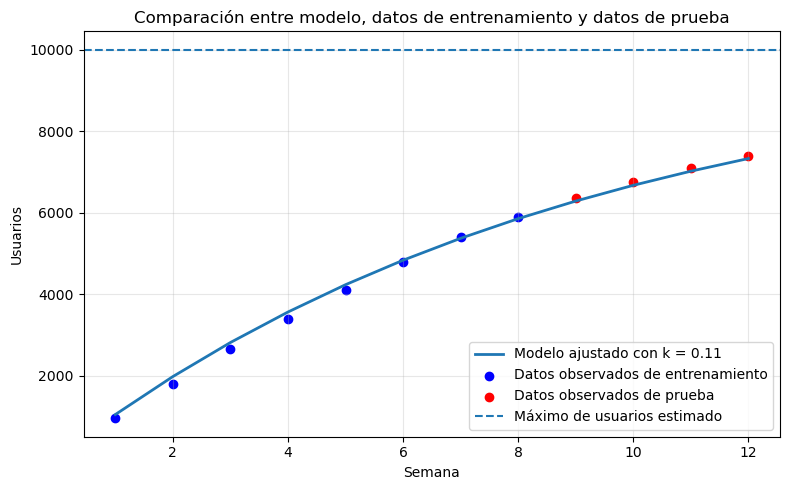

In [71]:
# Crear figura
plt.figure(figsize=(8, 5))
df_modelo  = simular_usuarios(k_train, L, semanas_totales)

plt.plot(
    df_modelo["semana"],
    df_modelo["usuarios_modelo"],
    label="Modelo ajustado con k = 0.11",
    linewidth=2
)

plt.scatter(
    df_train["semana"],
    df_train["usuarios_observados"],
    label="Datos observados de entrenamiento",
    color="blue"
)

plt.scatter(
    df_test["semana"],
    df_test["usuarios_observados"],
    label="Datos observados de prueba",
    color="red"
)

plt.axhline(
    y=L,
    linestyle="--",
    label="Máximo de usuarios estimado"
)

plt.xlabel("Semana")
plt.ylabel("Usuarios")
plt.title("Comparación entre modelo, datos de entrenamiento y datos de prueba")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Preguntas finales
1. ¿Cuál fue el mejor valor de (k) usando solamente los datos de entrenamiento?
 El mejor valor de $k$ usando solamente los datos de entrenamiento fué de $k=0.11$, totalmente igual al $k$ usando todos los datos.
2. ¿Cuál fue el RMSE en entrenamiento?
El RMSE de entrenamiento fué de 74.718597
3. ¿Cuál fue el RMSE en prueba?
El RMSE de prueba fué de 118.060581
4. ¿El modelo generaliza bien a las semanas que no se usaron para ajustar el parámetro?
El modelo sí generaliza bien las semanas que no se usaron para ajustarl el parámetro porque el RMSE es pequeño en comparación con el rango de los datos.
5. ¿Qué diferencia hay entre ajustar el parámetro usando todos los datos y ajustarlo usando solo entrenamiento?
Cuando se ajusta el parámetro usando todos los datos no se puede probar si el modelo generaliza bien el comportamiento de los datos, cuando se separan en datos de entrenamiento y datos de prueba entonces se puede probar que tanta capacidad de predicción tiene el modelo.
6. ¿Por qué es importante separar datos de entrenamiento y prueba?
Para probar la capacidad de predicción que tiene el modelo.